# ¿Que Trabajos y Habilidades son las Mejor Pagadas?

## Proposito del Notebook
- Comprar la mediana de los 5 trabajos mas solicitados 
- Encontrar la mediana para el top 10 habilidad que mejor pagadas, para el top 3 trabajos mas solicitados
- Encontrar la mediana para el top 10 habilidad que mas solicitadas, para el top 3 trabajos mas solicitados

## Cargar librerias y el archivo

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from rutas import ruta_archivo_limpio
import seaborn as sns 

df = pd.read_parquet(ruta_archivo_limpio())
df_trabajar = df.copy()
df_trabajar

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'programming': ['py..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'analyst_tools': None, 'programming': ['pytho..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'analyst_tools': None, 'programming': ['bash'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'analyst_tools': None, 'programming': ['bash'..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel'], 'pr..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'analyst_tools': None, 'programming': ['pytho..."


## Comparacion de la mediana de los 5 trabajos mas solicitados

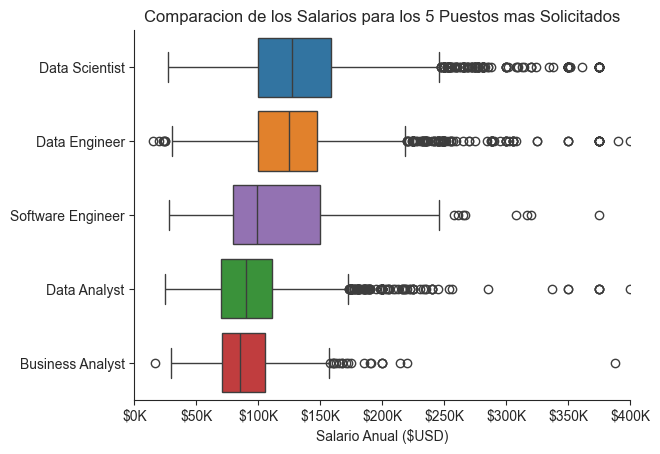

In [2]:
# top 5 trabajos 
top_5_trabajos = df_trabajar.job_title_short.value_counts().head(5).index.to_list()

# Orden de los 5 trabajos mas solicitados 
orden_trabajos = (df_trabajar[(df_trabajar.job_title_short.isin(top_5_trabajos)) & (df_trabajar.salary_year_avg.notna())]
                .groupby('job_title_short')['salary_year_avg']
                .median()
                .sort_values(ascending=False)
                .index
                .to_list()
)
# Filtramos por los top 5 trabajos 
df_media_compa = df_trabajar[(df_trabajar.job_title_short.isin(top_5_trabajos)) & (df_trabajar.salary_year_avg.notna())]

# Grafico y diseño 
sns.set_style(style='ticks')
sns.boxplot(data=df_media_compa,y='job_title_short',x='salary_year_avg',hue='job_title_short',palette='tab10',order=orden_trabajos)
sns.despine()
plt.title('Comparacion de los Salarios para los 5 Puestos mas Solicitados')
plt.ylabel('')
plt.xlabel('Salario Anual ($USD)')
plt.xlim(0,400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

## Mediana Trabajo Mejor Pagado y Trabajo mas Solicitado 

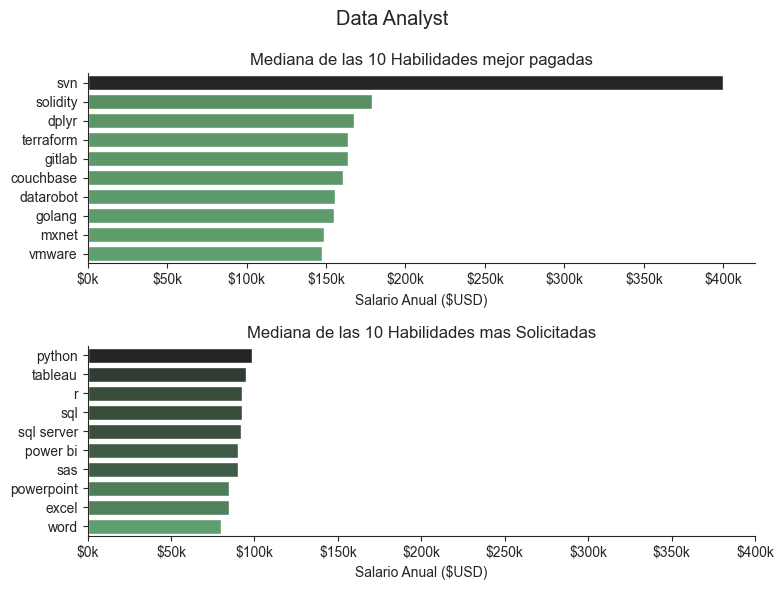

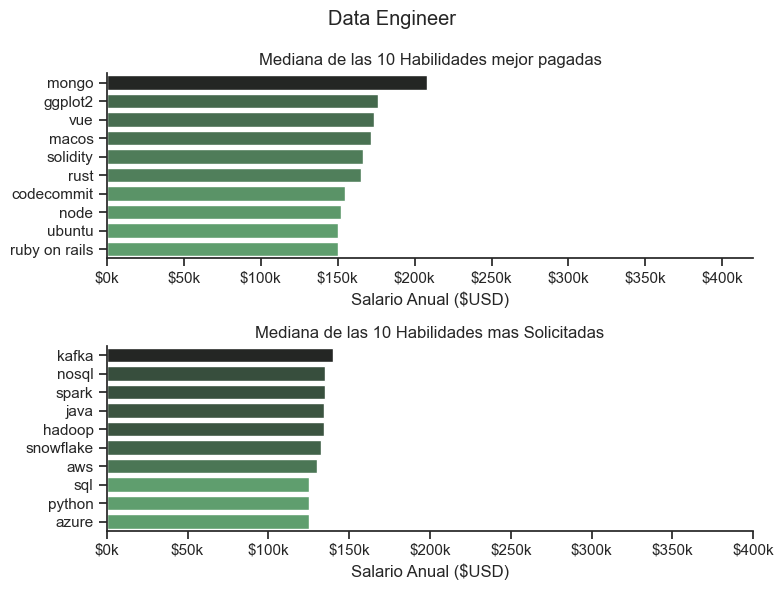

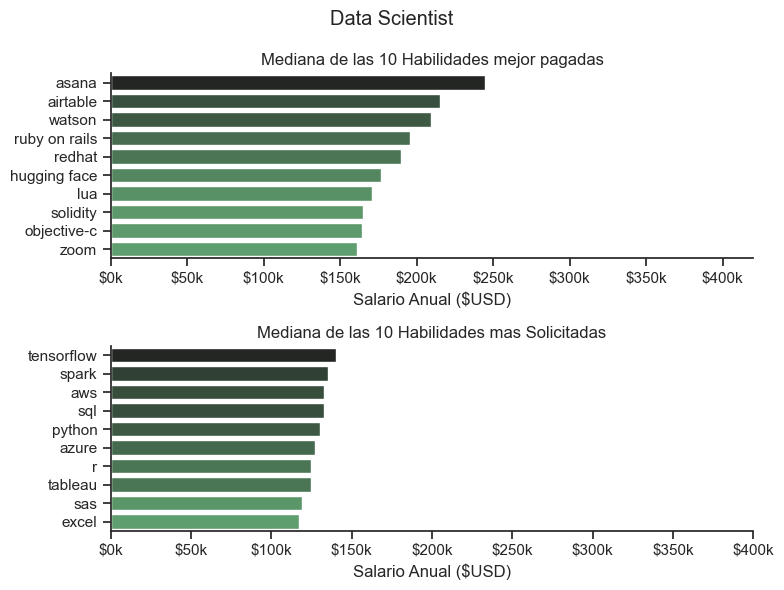

In [3]:
# top 3 trabajos 
top_3_trabajos = df_trabajar.job_title_short.value_counts().head(3).index.to_list()

for i, rol in enumerate(top_3_trabajos):
    fig, ax = plt.subplots(2,1,figsize =(8,6))
    
    sns.set_theme(style='ticks')
    
    df_filtrado = df_trabajar[(df_trabajar.job_title_short == rol) & (df_trabajar.salary_year_avg.notna())]
    
    #---------------------------------------
    # GRAFICO Mediana Habilidad Mejor Pagada
    #---------------------------------------
    g_mejor_pag = df_filtrado.explode('job_skills')
    g_mejor_pag = g_mejor_pag.groupby('job_skills').agg(
        mediana_salario_anual = ('salary_year_avg','median')
    ).sort_values(by='mediana_salario_anual',ascending=False).head(10)
    
    # Grafico y Diseño
    sns.barplot(data=g_mejor_pag,
                y=g_mejor_pag.index,
                x='mediana_salario_anual',
                ax=ax[0],
                hue='mediana_salario_anual',
                palette='dark:g_r',
                legend=False
    )
    ax[0].set_title('Mediana de las 10 Habilidades mejor pagadas')
    ax[0].set_ylabel('')
    ax[0].set_xlabel('Salario Anual ($USD)')
    ax[0].set_xlim(0,420000)
    ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
    
    #-----------------------------------------
    # GRAFICO Mediana Habilidad Mas Solicitada
    #-----------------------------------------
    g_mas_solicitado = df_filtrado.explode('job_skills')
    g_mas_solicitado = (
        g_mas_solicitado.groupby('job_skills')
        .agg(
        repeticiones_habilidad = ('job_skills','count'),
        mediana = ('salary_year_avg','median')
        )
        .sort_values(by='repeticiones_habilidad',ascending = False)
        .head(10)
        .sort_values(by='mediana',ascending=False)
    )
    
    sns.barplot(data=g_mas_solicitado,
                y=g_mas_solicitado.index,
                x='mediana',
                ax=ax[1],
                hue='mediana',
                palette='dark:g_r',
                legend=False
    )
    ax[1].set_title('Mediana de las 10 Habilidades mas Solicitadas')
    ax[1].set_ylabel('')
    ax[1].set_xlabel('Salario Anual ($USD)')
    ax[1].set_xlim(0,400000)
    ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
    
    #---------------------------
    # Diseño general del subplot
    #---------------------------
    sns.despine()
    fig.suptitle(rol)
    fig.tight_layout()